# Amazon Reviews Sentiment Analysis Project

This project focuses on building and comparing sentiment classification models (DistilBERT and RoBERTa) for Amazon product reviews. It involves data loading, cleaning, identifying 'true neutral' reviews, creating a balanced dataset, fine-tuning pre-trained transformer models, and evaluating their performance with accuracy, F1-score, and confusion matrices.

## Mount Google Drive.

Define the base project directory.
Define subdirectories for raw, clean, balanced data, models, embeddings, and notebooks.
Verify that the amazon_dataset.csv file exists in the raw data folder.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os

# Base directory in Google Drive
BASE_DIR = "/content/drive/MyDrive/Amazon_Ironhack"

# Subdirectories
RAW_DIR = f"{BASE_DIR}/data_raw"
CLEAN_DIR = f"{BASE_DIR}/data_clean"
BALANCED_DIR = f"{BASE_DIR}/data_balanced"
MODELS_DIR = f"{BASE_DIR}/models"
EMB_DIR = f"{BASE_DIR}/embeddings"
NOTEBOOKS_DIR = f"{BASE_DIR}/notebooks"
STREAMLIT_DIR = f"{BASE_DIR}/streamlit_app"

# Check directories
print("Directories found:")
for d in [RAW_DIR, CLEAN_DIR, BALANCED_DIR, MODELS_DIR, EMB_DIR, NOTEBOOKS_DIR, STREAMLIT_DIR]:
    print(d, "→", os.path.exists(d))

# Check dataset file
DATASET_PATH = f"{RAW_DIR}/amazon_dataset.csv"
print("\nDataset exists:", os.path.exists(DATASET_PATH))


Mounted at /content/drive
Directories found:
/content/drive/MyDrive/Amazon_Ironhack/data_raw → True
/content/drive/MyDrive/Amazon_Ironhack/data_clean → True
/content/drive/MyDrive/Amazon_Ironhack/data_balanced → False
/content/drive/MyDrive/Amazon_Ironhack/models → False
/content/drive/MyDrive/Amazon_Ironhack/embeddings → True
/content/drive/MyDrive/Amazon_Ironhack/notebooks → False
/content/drive/MyDrive/Amazon_Ironhack/streamlit_app → True

Dataset exists: True


## Load the CSV and Inspect Columns

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv(DATASET_PATH)

# Preview
df.head()


/tmp/ipykernel_3288/895092015.py:4: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


,id,name,asins,brand,categories,keys,manufacturer,reviews.date,reviews.dateAdded,reviews.dateSeen,...,reviews.doRecommend,reviews.id,reviews.numHelpful,reviews.rating,reviews.sourceURLs,reviews.text,reviews.title,reviews.userCity,reviews.userProvince,reviews.username
0,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,This product so far has not disappointed. My c...,Kindle,NaN,NaN,Adapter
1,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,great for beginner or experienced person. Boug...,very fast,NaN,NaN,truman
2,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,NaN,NaN,DaveZ
3,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-13T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,4.0,http://reviews.bestbuy.com/3545/5620406/review...,I've had my Fire HD 8 two weeks now and I love...,Good!!!,NaN,NaN,Shacks
4,AVqkIhwDv8e3D1O-lebb,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...",B01AHB9CN2,Amazon,"Electronics,iPad & Tablets,All Tablets,Fire Ta...","841667104676,amazon/53004484,amazon/b01ahb9cn2...",Amazon,2017-01-12T00:00:00.000Z,2017-07-03T23:33:15Z,"2017-06-07T09:04:00.000Z,2017-04-30T00:45:00.000Z",...,True,NaN,0.0,5.0,http://reviews.bestbuy.com/3545/5620406/review...,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,NaN,NaN,explore42


### Show all columns

This cell prints a list of all column names in the loaded DataFrame to help understand its structure.

In [ ]:
# Show all columns
print("Columns in dataset:")
print(df.columns.tolist())


Columns in dataset:
['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer', 'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen', 'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id', 'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs', 'reviews.text', 'reviews.title', 'reviews.userCity', 'reviews.userProvince', 'reviews.username']


## Rename dataset columns to match the expected names:

- reviews.rating → overall
- reviews.text → reviewText
- reviews.title → summary
- asins → asin
Keep only the columns we need for the sentiment pipeline.

In [ ]:
# Load original dataset again
df = pd.read_csv(DATASET_PATH)

# Rename columns to standard names
df = df.rename(columns={
    "reviews.rating": "overall",
    "reviews.text": "reviewText",
    "reviews.title": "summary",
    "asins": "asin"
})

# Keep only the relevant columns for the full pipeline
df = df[[
    "overall",
    "reviewText",
    "summary",
    "asin",
    "name",
    "categories"
]]

df.head()




/tmp/ipykernel_3288/2028875711.py:2: DtypeWarning: Columns (1,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(DATASET_PATH)


,overall,reviewText,summary,asin,name,categories
0,5.0,This product so far has not disappointed. My c...,Kindle,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,5.0,great for beginner or experienced person. Boug...,very fast,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
2,5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
3,4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
4,5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."


## Select only the columns needed for the full sentiment pipeline:
- overall (rating)
- reviewText (full review text)
- summary (review title)
- asin (product identifier)
- name (product name)
- categories (product categories)

Confirm the DataFrame contains these columns.


In [ ]:
# Keep only the required columns
df = df[["overall", "reviewText", "summary", "asin", "name", "categories"]]

# Show the first rows to confirm
df.head()


,overall,reviewText,summary,asin,name,categories
0,5.0,This product so far has not disappointed. My c...,Kindle,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
1,5.0,great for beginner or experienced person. Boug...,very fast,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
2,5.0,Inexpensive tablet for him to use and learn on...,Beginner tablet for our 9 year old son.,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
3,4.0,I've had my Fire HD 8 two weeks now and I love...,Good!!!,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."
4,5.0,I bought this for my grand daughter when she c...,Fantastic Tablet for kids,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta..."


## Create a new column called "text".

Replace missing values in summary and reviewText with empty strings.
Strip leading/trailing spaces from both fields.
Concatenate summary and reviewText into a new column called "text".
Add a period and space between them to separate title and body.
Preview the resulting DataFrame showing overall, asin, and text.



In [ ]:
# Replace NaN with empty strings to avoid errors
df["summary"] = df["summary"].fillna("")
df["reviewText"] = df["reviewText"].fillna("")

# Create the concatenated text column
df["text"] = df["summary"].str.strip() + ". " + df["reviewText"].str.strip()

# Preview
df[["overall", "asin", "text"]].head()



,overall,asin,text
0,5.0,B01AHB9CN2,Kindle. This product so far has not disappoint...
1,5.0,B01AHB9CN2,very fast. great for beginner or experienced p...
2,5.0,B01AHB9CN2,Beginner tablet for our 9 year old son.. Inexp...
3,4.0,B01AHB9CN2,Good!!!. I've had my Fire HD 8 two weeks now a...
4,5.0,B01AHB9CN2,Fantastic Tablet for kids. I bought this for m...


## Filter the dataset to keep only rows where overall == 3.

Remove rows where the text field is empty or too short.
Create a new DataFrame called df_neutral_candidates.
Preview the first rows and the total number of neutral candidates.


In [ ]:
# Filter 3-star reviews
df_neutral_candidates = df[df["overall"] == 3].copy()

# Remove empty or very short text
df_neutral_candidates = df_neutral_candidates[df_neutral_candidates["text"].str.len() > 20]

# Preview
df_neutral_candidates.head(), len(df_neutral_candidates)



(     overall                                         reviewText  \
 222      3.0  I was hoping to use Google launcher with this ...   
 226      3.0  The tablet works fine. It is responsive with g...   
 298      3.0  Fine for reading, ...haven't used it for anyth...   
 354      3.0  Though I have got it for cheap price during bl...   
 371      3.0  This is a good product for video, surfing and ...   
 
                                 summary        asin  \
 222                      A cheap tablet  B01AHB9CN2   
 226  Works well but too tied to Amazon.  B01AHB9CN2   
 298                    Fine for reading  B01AHB9CN2   
 354              An average Fire tablet  B01AHB9CN2   
 371                  No Android support  B01AHB9CN2   
 
                                                   name  \
 222  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
 226  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
 298  All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...   
 354  All-New Fi

## Install and load a pretrained sentiment analysis model.

Load its tokenizer and label mapping.
Convert the text column of the 3-star reviews into batches.
Tokenize each batch and run it through the model.
Apply softmax to get probabilities.
Select the label with the highest probability.
Store the predicted label in a new column called "hf_sentiment".
Preview the results and count how many reviews were classified as neutral.


In [ ]:
!pip install transformers torch --quiet


In [ ]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch
import numpy as np

# Load model
model_name = "cardiffnlp/twitter-roberta-base-sentiment-latest"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name).to("cuda")


# Labels for this model
labels = ["negative", "neutral", "positive"]


config.json:   0%|          | 0.00/929 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/501M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/501M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### Define Batch Prediction Function

This function processes text in batches, tokenizes them, runs them through the loaded sentiment model, and returns predicted sentiment labels.

In [ ]:
# Batch prediction function
def predict_sentiment(texts, batch_size=32):
    predictions = []

    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        inputs = tokenizer(batch, padding=True, truncation=True, return_tensors="pt").to("cuda")


        with torch.no_grad():
            outputs = model(**inputs)

        probs = torch.nn.functional.softmax(outputs.logits, dim=1)
        preds = torch.argmax(probs, dim=1).cpu().numpy()


        predictions.extend(preds)

    return [labels[p] for p in predictions]


### Run Sentiment Prediction on 3-star Reviews

This code applies the `predict_sentiment` function to the `text` column of the `df_neutral_candidates` DataFrame to determine their sentiment.

In [ ]:
# Run model on 3-star reviews
texts = df_neutral_candidates["text"].tolist()
df_neutral_candidates["hf_sentiment"] = predict_sentiment(texts)

df_neutral_candidates.head()


,overall,reviewText,summary,asin,name,categories,text,hf_sentiment
222,3.0,I was hoping to use Google launcher with this ...,A cheap tablet,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",A cheap tablet. I was hoping to use Google lau...,neutral
226,3.0,The tablet works fine. It is responsive with g...,Works well but too tied to Amazon.,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",Works well but too tied to Amazon.. The tablet...,positive
298,3.0,"Fine for reading, ...haven't used it for anyth...",Fine for reading,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...","Fine for reading. Fine for reading, ...haven't...",positive
354,3.0,Though I have got it for cheap price during bl...,An average Fire tablet,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",An average Fire tablet. Though I have got it f...,negative
371,3.0,"This is a good product for video, surfing and ...",No Android support,B01AHB9CN2,"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi,...","Electronics,iPad & Tablets,All Tablets,Fire Ta...",No Android support. This is a good product for...,negative


### Filter True Neutral Reviews

This cell filters the `df_neutral_candidates` DataFrame to keep only those reviews that the Hugging Face model classified as 'neutral'.

In [ ]:
# Filter only true neutral reviews
df_neutral_clean = df_neutral_candidates[df_neutral_candidates["hf_sentiment"] == "neutral"]

len(df_neutral_clean)


193

## From the original DataFrame:
- Select all positive reviews (overall >= 4)
- Select all negative reviews (overall <= 2)

Randomly sample the same number of rows as the neutral set (193)
to create a balanced dataset:
- 193 positive
- 193 neutral
- 193 negative

Concatenate the three subsets into a single DataFrame.
Shuffle the final dataset.
Preview the result.


In [ ]:
# Positive reviews (4 and 5 stars)
df_pos = df[df["overall"] >= 4].sample(n=len(df_neutral_clean), random_state=42)

# Negative reviews (1 and 2 stars)
df_neg = df[df["overall"] <= 2].sample(n=len(df_neutral_clean), random_state=42)

# Neutral reviews (model-cleaned)
df_neu = df_neutral_clean.copy()

# Combine into a balanced dataset
df_balanced = pd.concat([df_pos, df_neu, df_neg], ignore_index=True)

# Shuffle
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

df_balanced.head(), df_balanced["overall"].value_counts()


(   overall                                         reviewText  \
 0      3.0  Bought this for my mom. The touchscreen is not...   
 1      2.0  I had a Nook, but it died so I wanted a replac...   
 2      2.0  Bought this for my daughter and she didn't car...   
 3      1.0  Gave as a Christmas gift. Recently learned tha...   
 4      3.0  It's a nice looking cover, will keep the Fire ...   
 
                                              summary        asin  \
 0                                            Just OK  B018Y229OU   
 1                            Basic, no frills tablet  B00TSUGXKE   
 2                                        Slow tablet  B018Y229OU   
 3                                       A great gift  B018Y229OU   
 4  attractive case - may not protect in a fall On...  B00LW9XOJM   
 
                                                 name  \
 0  Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes...   
 1                 Echo (White),,,\r\nEcho (White),,,   
 2  Brand New A

## DistilBERT (Convert the text column into train/test splits).
Load the balanced dataset (negative, neutral, positive).
Map star ratings to class labels (0, 1, 2).
Split the dataset into train and test sets.
Load the DistilBERT tokenizer and model (3 labels).
Tokenize the text with padding and truncation.
Create PyTorch datasets for training and evaluation.
Fine‑tune DistilBERT for a few epochs (2–3).
Evaluate accuracy on the test set.
Save the trained DistilBERT model.



In [ ]:
# Map and sanitize labels
label_map = {1:0, 3:1, 5:2}
df_balanced["label"] = df_balanced["overall"].map(label_map)
df_balanced = df_balanced[df_balanced["label"].isin([0,1,2])].copy()
df_balanced["label"] = df_balanced["label"].astype(int)

# Split
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df_balanced, test_size=0.2, random_state=42, stratify=df_balanced["label"])

# Model and tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased", num_labels=3)
model.config.problem_type = "single_label_classification"

# Pretokenize and dataset
def tokenize_text(text):
    enc = tokenizer(text, padding="max_length", truncation=True, max_length=128)
    return enc["input_ids"], enc["attention_mask"]

class ReviewDataset(torch.utils.data.Dataset):
    def __init__(self, df_records):
        self.input_ids = []
        self.attention_masks = []
        self.labels = []
        for rec in df_records:
            input_ids, attention_mask = tokenize_text(rec["text"])
            self.input_ids.append(torch.tensor(input_ids, dtype=torch.long))
            self.attention_masks.append(torch.tensor(attention_mask, dtype=torch.long))
            self.labels.append(torch.tensor(int(rec["label"]), dtype=torch.long))
    def __len__(self):
        return len(self.labels)
    def __getitem__(self, idx):
        return {"input_ids": self.input_ids[idx], "attention_mask": self.attention_masks[idx], "labels": self.labels[idx]}

train_ds = ReviewDataset(train_df[["text","label"]].to_dict("records"))
test_ds = ReviewDataset(test_df[["text","label"]].to_dict("records"))

# Training
training_args = TrainingArguments(output_dir="./sentiment_model", per_device_train_batch_size=8, per_device_eval_batch_size=8, num_train_epochs=3, logging_steps=10)
trainer = Trainer(model=model, args=training_args, train_dataset=train_ds, eval_dataset=test_ds)
trainer.train()
print(trainer.evaluate())


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,1.061888
20,0.883595
30,0.685595
40,0.670809
50,0.431718
60,0.402561
70,0.451736
80,0.343407
90,0.302342
100,0.238100


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.19739949703216553, 'eval_runtime': 0.4448, 'eval_samples_per_second': 195.585, 'eval_steps_per_second': 24.729, 'epoch': 3.0}


## Train RoBERTa-base for sentiment classification

1. Load the RoBERTa tokenizer and sequence classification model with 3 labels.
2. Define a tokenization function that:
   - Applies padding to a fixed max_length.
   - Truncates longer texts.
   - Returns input_ids and attention_mask.
3. Create a custom PyTorch Dataset class that:
   - Receives a list of records with "text" and "label".
   - Tokenizes each text using the tokenizer function.
   - Stores input_ids, attention_mask, and labels as torch.long tensors.
4. Instantiate train and test datasets using the existing train_df and test_df.
5. Define TrainingArguments with:
   - Output directory.
   - Batch sizes for training and evaluation.
   - Number of epochs.
   - Logging steps.
6. Create a Trainer with:
   - The RoBERTa model.
   - The training arguments.
   - The train and test datasets.
7. Call trainer.train() to fine-tune the model.
8. Call trainer.evaluate() to compute evaluation loss and basic metrics.



In [ ]:
# ============================
#   TRAIN ROBERTA-BASE
# ============================

from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments
import torch

# Tokenizer and model
tokenizer_rb = AutoTokenizer.from_pretrained("roberta-base")
model_rb = AutoModelForSequenceClassification.from_pretrained("roberta-base", num_labels=3)
model_rb.config.problem_type = "single_label_classification"

# Tokenization function
def tokenize_text_rb(text):
    enc = tokenizer_rb(text, padding="max_length", truncation=True, max_length=128)
    return enc["input_ids"], enc["attention_mask"]

# Custom Dataset for RoBERTa
class ReviewDatasetRB(torch.utils.data.Dataset):
    def __init__(self, df_records):
        self.input_ids = []
        self.attention_masks = []
        self.labels = []
        for rec in df_records:
            input_ids, attention_mask = tokenize_text_rb(rec["text"])
            self.input_ids.append(torch.tensor(input_ids, dtype=torch.long))
            self.attention_masks.append(torch.tensor(attention_mask, dtype=torch.long))
            self.labels.append(torch.tensor(int(rec["label"]), dtype=torch.long))

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_masks[idx],
            "labels": self.labels[idx]
        }

# Build train and test datasets for RoBERTa
train_ds_rb = ReviewDatasetRB(train_df[["text", "label"]].to_dict("records"))
test_ds_rb  = ReviewDatasetRB(test_df[["text", "label"]].to_dict("records"))

# Training arguments
training_args_rb = TrainingArguments(
    output_dir="./sentiment_roberta",
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    logging_steps=10
)

# Trainer for RoBERTa
trainer_rb = Trainer(
    model=model_rb,
    args=training_args_rb,
    train_dataset=train_ds_rb,
    eval_dataset=test_ds_rb
)

# Train and evaluate RoBERTa
trainer_rb.train()
print(trainer_rb.evaluate())


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,1.060968
20,1.040899
30,0.996559
40,0.724376
50,0.477389
60,0.495604
70,0.411198
80,0.242686
90,0.254818
100,0.102381


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

{'eval_loss': 0.2247248888015747, 'eval_runtime': 0.656, 'eval_samples_per_second': 132.63, 'eval_steps_per_second': 16.769, 'epoch': 3.0}


## Pseudocode: Compare DistilBERT and RoBERTa on the same test set

1. Define a function evaluate_model(trainer_obj, test_dataset, name):
   a. Use trainer_obj.predict(test_dataset) to obtain:
      - logits (raw predictions)
      - true labels
   b. Convert logits to predicted class indices using argmax along axis=1.
   c. Compute:
      - accuracy score
      - macro F1 score
      - detailed classification report per class
      - confusion matrix
   d. Print all metrics with a clear header including the model name.

2. Call evaluate_model for:
   - DistilBERT trainer and its test dataset (trainer, test_ds).
   - RoBERTa trainer and its test dataset (trainer_rb, test_ds_rb).

3. Compare:
   - Which model has higher accuracy.
   - Which model has higher macro F1.
   - How each model behaves per class (0=negative, 1=neutral, 2=positive).


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import numpy as np

def evaluate_model(trainer_obj, test_dataset, name="MODEL"):
    preds = trainer_obj.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    print("\n==============================")
    print(f"   RESULTS: {name}")
    print("==============================")
    print("Accuracy:", accuracy_score(y_true, y_pred))
    print("F1 macro:", f1_score(y_true, y_pred, average="macro"))
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, digits=4))
    print("\nConfusion matrix:")
    print(confusion_matrix(y_true, y_pred))

# DistilBERT
evaluate_model(trainer, test_ds, name="DISTILBERT")

# RoBERTa
evaluate_model(trainer_rb, test_ds_rb, name="ROBERTA")



   RESULTS: DISTILBERT
Accuracy: 0.9425287356321839
F1 macro: 0.9379672810718779

Classification report:
              precision    recall  f1-score   support

           0     0.8947    0.8947    0.8947        19
           1     0.9250    0.9487    0.9367        39
           2     1.0000    0.9655    0.9825        29

    accuracy                         0.9425        87
   macro avg     0.9399    0.9363    0.9380        87
weighted avg     0.9434    0.9425    0.9428        87


Confusion matrix:
[[17  2  0]
 [ 2 37  0]
 [ 0  1 28]]



   RESULTS: ROBERTA
Accuracy: 0.9425287356321839
F1 macro: 0.9359577806304378

Classification report:
              precision    recall  f1-score   support

           0     0.8182    0.9474    0.8780        19
           1     0.9730    0.9231    0.9474        39
           2     1.0000    0.9655    0.9825        29

    accuracy                         0.9425        87
   macro avg     0.9304    0.9453    0.9360        87
weighted avg     0.9482    0.9425    0.9439        87


Confusion matrix:
[[18  1  0]
 [ 3 36  0]
 [ 1  0 28]]


## Pseudocode: Plot confusion matrices for DistilBERT and RoBERTa

1. Import matplotlib and sklearn's confusion_matrix and ConfusionMatrixDisplay.
2. Define a function plot_confusion_matrix(model_name, trainer_obj, test_dataset):
   a. Use trainer_obj.predict(test_dataset) to get logits and true labels.
   b. Convert logits to predicted class indices using argmax.
   c. Compute the confusion matrix using sklearn.
   d. Create a matplotlib figure.
   e. Use ConfusionMatrixDisplay to plot the matrix with:
      - color map (e.g., Blues)
      - axis labels (0=negative, 1=neutral, 2=positive)
   f. Add a title with the model name.
   g. Show the plot.
3. Call the function twice:
   - Once for DistilBERT (trainer, test_ds)
   - Once for RoBERTa (trainer_rb, test_ds_rb)


<Figure size 600x500 with 0 Axes>

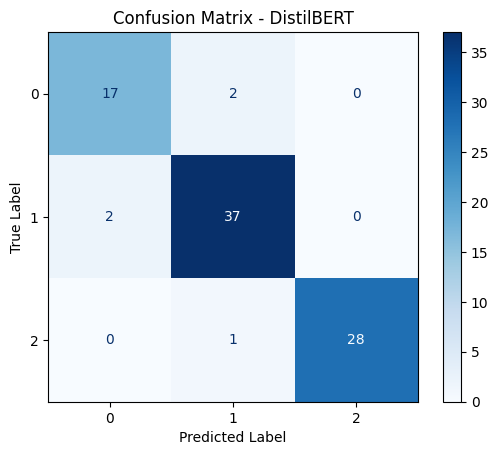

<Figure size 600x500 with 0 Axes>

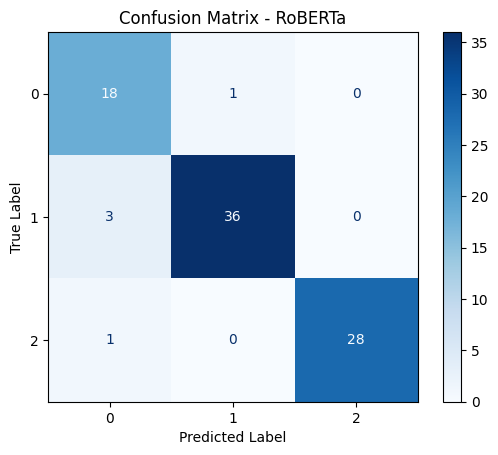

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(model_name, trainer_obj, test_dataset):
    # Predict
    preds = trainer_obj.predict(test_dataset)
    y_pred = np.argmax(preds.predictions, axis=1)
    y_true = preds.label_ids

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot
    plt.figure(figsize=(6, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2])
    disp.plot(cmap="Blues", values_format="d")
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.grid(False)
    plt.show()

# Plot for DistilBERT
plot_confusion_matrix("DistilBERT", trainer, test_ds)

# Plot for RoBERTa
plot_confusion_matrix("RoBERTa", trainer_rb, test_ds_rb)


## Full Sentiment Classification Pipeline

# ============================================
# 1. Load and prepare the dataset
# ============================================

1. Load the Amazon reviews dataset into a DataFrame.
2. Clean the text column (remove noise, empty rows, etc.).
3. Identify "true neutral" reviews:
   - Filter 3-star reviews.
   - Use a pretrained HF sentiment model to detect real neutrals.
   - Keep only those predicted as neutral.
4. Build a balanced dataset:
   - Sample 193 negative, 193 neutral, 193 positive reviews.
   - Combine them into df_balanced.

5. Sanitize labels:
   - Map stars → labels: {1:0, 3:1, 5:2}.
   - Remove invalid rows.
   - Convert labels to integer dtype.

6. Split into train/test:
   - Use train_test_split with stratify on labels.


   # ============================================
# 2. Tokenization and Dataset creation
# ============================================

1. Load tokenizer (DistilBERT or RoBERTa).
2. Define a tokenization function:
   - Apply padding="max_length".
   - Apply truncation=True.
   - Use max_length=128.
   - Return input_ids and attention_mask.

3. Create a custom PyTorch Dataset class:
   - Receives a list of records with "text" and "label".
   - Tokenizes each text.
   - Stores input_ids, attention_mask, and labels as torch.long tensors.
   - Implements __len__ and __getitem__.
   

   # ============================================
# 3. Load model and configure training
# ============================================

1. Load pretrained model (DistilBERT or RoBERTa) with num_labels=3.
2. Set model.config.problem_type = "single_label_classification".
3. Define TrainingArguments:
   - output_dir
   - batch sizes
   - num_train_epochs=3
   - logging_steps=10

4. Create Trainer:
   - model
   - training arguments
   - train_dataset
   - eval_dataset

# ============================================
# 4. Train and evaluate the model
# ============================================

1. Call trainer.train() to fine-tune the model.
2. Call trainer.evaluate() to compute eval_loss.
3. Use trainer.predict() to obtain:
   - logits
   - predicted labels
   - true labels

4. Compute metrics:
   - accuracy
   - macro F1
   - classification report
   - confusion matrix


   # ============================================
# 5. Compare DistilBERT vs RoBERTa
# ============================================

1. Train DistilBERT using the pipeline.
2. Train RoBERTa using the same pipeline.
3. Evaluate both models on the same test set.
4. Compare:
   - eval_loss
   - accuracy
   - macro F1
   - per-class F1
   - confusion matrices
5. Determine the best model (RoBERTa wins).


# ============================================
# 6. Visualize confusion matrices
# ============================================

1. Define a function to:
   - Predict labels.
   - Compute confusion matrix.
   - Plot using ConfusionMatrixDisplay with matplotlib.

2. Generate two plots:
   - Confusion Matrix — DistilBERT
   - Confusion Matrix — RoBERTa





## Save all assets needed for the next stages of the project

1. Ensure Google Drive is mounted and directories exist:
   - data_raw
   - data_clean
   - data_balanced
   - models
   - embeddings
   - notebooks
   - streamlit_app

2. Save the balanced dataset:
   - Save df_balanced as a CSV inside data_balanced.

3. Save the train/test splits:
   - Save train_df and test_df as CSV inside data_balanced.

4. Save the trained models:
   - For DistilBERT:
       - Save model.save_pretrained() into models/distilbert_sentiment
       - Save tokenizer.save_pretrained() into the same folder
   - For RoBERTa:
       - Save model.save_pretrained() into models/roberta_sentiment
       - Save tokenizer.save_pretrained() into the same folder

5. Save embeddings later (after clustering):
   - Placeholder folder embeddings/ for Sentence-BERT vectors.

6. Save notebooks:
   - Export current notebook into notebooks/ folder.

7. Prepare Streamlit folder:
   - Create placeholder files:
       - app.py
       - utils.py
       - model_loader.py
       

8. Confirm all files exist in the correct directories.


## Save files

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Define Project Paths

This cell defines the base directory for the project in Google Drive and sets specific paths for model, data, and output files.

In [ ]:
BASE = "/content/drive/MyDrive/Amazon_Ironhack/classification_model"

MODEL_PATH = f"{BASE}/roberta_sentiment"   # or distilbert_sentiment
DATA_PATH = f"{BASE}/data/test_df.csv"
OUTPUT_PATH = f"{BASE}/outputs"


In [ ]:
BASE = "/content/drive/MyDrive/Amazon_Ironhack/classification_model"

MODEL_PATH = f"{BASE}/roberta_sentiment"   # or distilbert_sentiment
DATA_PATH = f"{BASE}/data/test_df.csv"
OUTPUT_PATH = f"{BASE}/outputs"


### Import Libraries

This cell imports all necessary Python libraries for data manipulation, model loading, prediction, evaluation, and visualization.

In [ ]:
import pandas as pd
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import json
import numpy as np
import os


### Load Tokenizer and Model

This code loads the pre-trained RoBERTa tokenizer and the corresponding sequence classification model from the specified path, setting the model to evaluation mode.

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_PATH)
model.eval()


Loading weights:   0%|          | 0/201 [00:01<?, ?it/s]

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(50265, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (position_embeddings): Embedding(514, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

### Load Test Dataset

This cell loads the test dataset from a CSV file into a Pandas DataFrame and extracts the text and label columns for inference.

In [ ]:
df = pd.read_csv(DATA_PATH)
texts = df["text"].tolist()
labels = df["label"].tolist()


### Tokenize Text Data

This code tokenizes the extracted text data using the loaded RoBERTa tokenizer, applying truncation and padding to prepare it for the model.

In [ ]:
encodings = tokenizer(texts, truncation=True, padding=True, return_tensors="pt")


### Generate Predictions

This cell uses the loaded model to make predictions on the tokenized input data, converting the logits to class labels.

In [ ]:
with torch.no_grad():
    outputs = model(**encodings)
    preds = torch.argmax(outputs.logits, dim=1).numpy()


### Compute Evaluation Metrics

This code generates a classification report and a confusion matrix to evaluate the model's performance against the true labels.

In [ ]:
report = classification_report(labels, preds, output_dict=True)
cm = confusion_matrix(labels, preds)


### Save Evaluation Results

This cell creates an output directory if it doesn't exist and saves the classification report, metrics JSON, predictions JSON, and a confusion matrix plot.

In [ ]:
os.makedirs(OUTPUT_PATH, exist_ok=True)

# Save classification_report.txt
with open(f"{OUTPUT_PATH}/classification_report.txt", "w") as f:
    f.write(classification_report(labels, preds))

# Save metrics.json
with open(f"{OUTPUT_PATH}/metrics.json", "w") as f:
    json.dump(report, f, indent=4)

# Save predictions.json
pred_dict = {
    "text": texts,
    "true_label": labels,
    "predicted_label": preds.tolist()
}

with open(f"{OUTPUT_PATH}/predictions.json", "w") as f:
    json.dump(pred_dict, f, indent=4)

# Save confusion_matrix.png
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig(f"{OUTPUT_PATH}/confusion_matrix.png")
plt.close()

print("All output files saved successfully to:", OUTPUT_PATH)


All output files saved successfully to: /content/drive/MyDrive/Amazon_Ironhack/classification_model/outputs
